
# 6. Quality

Этот notebook считает только статистику по уже готовым артефактам из `artifacts/score` и `artifacts/project`.
Он **не** перезапускает `infer` и **не** перезапускает `align`.

Фокус здесь не на `semantic quality` вообще, а на **quality of model alignment**.

Идея такая:
- `feedback` меняет именование и часто снижает поверхностное lexical overlap;
- поэтому усреднение по всем matcher'ам и по смешанной метрике может прятать реальный gain;
- нужно смотреть на alignment-метрики и alignment-slices, которые лучше отражают semantic/structural matchability.

В этом notebook используются три уровня анализа:
1. `coverage_f1` для same-scenario пар как базовая alignment-метрика покрытия.
2. `pair_alignment_f1` на semantic/structure-aware matcher'ах, где feedback должен помогать сильнее.
3. Отдельный срез `valentine:coma_py`, где проверяется, видно ли `feedback > guided > control` по всем directed model-pair comparisons.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12

SCENARIO_ORDER = ['control', 'guided', 'feedback']
SCENARIO_PALETTE = {
    'control': '#6b7280',
    'guided': '#1d4ed8',
    'feedback': '#059669',
}
MODEL_SHORT_NAMES = {
    'google/gemini-2.5-flash-lite': 'Gemini',
    'meta-llama/llama-3.2-3b-instruct': 'Llama',
    'mistralai/ministral-3b-2512': 'Ministral',
}
SEMANTIC_MATCHERS = [('valentine', 'coma_py'), ('bdikit', 'coma')]


def find_repo_root(start: Path | None = None) -> Path:
    cursor = (start or Path.cwd()).resolve()
    for candidate in [cursor, *cursor.parents]:
        if (candidate / 'artifacts' / 'score' / 'pair-scores.csv').exists():
            return candidate
    raise FileNotFoundError(
        'Could not find repo root containing artifacts/score/pair-scores.csv'
    )


def short_model_name(model: str) -> str:
    return MODEL_SHORT_NAMES.get(model, model.rsplit('/', 1)[-1])


def annotate_bars(ax: plt.Axes, fmt: str = '{:.3f}') -> None:
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append('' if pd.isna(height) else fmt.format(height))
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)


repo_root = find_repo_root()
score_dir = repo_root / 'artifacts' / 'score'
project_dir = repo_root / 'artifacts' / 'project' / 'extracted'

pair_scores = pd.read_csv(score_dir / 'pair-scores.csv')
model_index = pd.read_csv(project_dir / 'model_index.csv')
elements = pd.read_csv(project_dir / 'elements.csv')

same = pair_scores[
    pair_scores['source_condition'] == pair_scores['target_condition']
].copy()
same['source_condition'] = pd.Categorical(
    same['source_condition'],
    categories=SCENARIO_ORDER,
    ordered=True,
)
same['method_label'] = same['backend'] + ':' + same['method']
same['source_model_short'] = same['source_producer_id'].map(short_model_name)
same['target_model_short'] = same['target_producer_id'].map(short_model_name)
same['model_pair_label'] = (
    same['source_model_short'] + ' → ' + same['target_model_short']
)
same['is_semantic_matcher'] = [
    (backend, method) in SEMANTIC_MATCHERS
    for backend, method in zip(same['backend'], same['method'], strict=True)
]
semantic_same = same[same['is_semantic_matcher']].copy()
valentine_coma = same[
    (same['backend'] == 'valentine') & (same['method'] == 'coma_py')
].copy()

semantic_matchers_used_here = ', '.join(
    f'{backend}:{method}' for backend, method in SEMANTIC_MATCHERS
)
directed_model_pairs = (
    same[['source_producer_id', 'target_producer_id']]
    .drop_duplicates()
    .shape[0]
)
alignment_methods = same[['backend', 'method']].drop_duplicates().shape[0]
summary = pd.DataFrame(
    {
        'pair_score_rows': [len(pair_scores)],
        'same_scenario_rows': [len(same)],
        'documents': [same['source_document_id'].nunique()],
        'directed_model_pairs': [directed_model_pairs],
        'alignment_methods': [alignment_methods],
        'semantic_matchers_used_here': [semantic_matchers_used_here],
    }
)

display(Markdown(f'**Repo root:** `{repo_root}`'))
display(summary)

**Repo root:** `/home/bearpro/source/personal/llm-in-lsp-experiment`

,pair_score_rows,same_scenario_rows,documents,directed_model_pairs,alignment_methods,semantic_matchers_used_here
0,13165,3284,6,6,11,"valentine:coma_py, bdikit:coma"



## Metric choice

В старом виде `pair_alignment_f1 = coverage_f1 * top1_mean_score` смешивает две разные вещи:
- `coverage_f1`: насколько хорошо matcher покрывает элементы двух моделей;
- `top1_mean_score`: насколько высоки сами matcher-score, которые у lexical методов сильно зависят от surface naming.

Для feedback это критично: он специально переписывает naming, чтобы убрать неоднозначность. Это часто улучшает semantic/structural alignment, но может слегка ухудшить raw lexical similarity.

Поэтому ниже используются два alignment-centric среза:
- **All methods / same-scenario `coverage_f1`**: самый честный глобальный сигнал по покрытию.
- **Semantic matcher slice / same-scenario `pair_alignment_f1`**: только `valentine:coma_py` и `bdikit:coma`, чтобы убрать часть lexical bias.


### Numeric summary

**All methods / same-scenario**

,coverage_f1,top1_mean_score,pair_alignment_f1
source_condition,,,
Control,0.5336,0.5646,0.2853
Guided,0.5410,0.5387,0.2821
Feedback,0.5557,0.5175,0.2811


**Semantic matcher slice / same-scenario**

,coverage_f1,top1_mean_score,pair_alignment_f1
source_condition,,,
Control,0.5751,0.7159,0.4172
Guided,0.6268,0.7258,0.4651
Feedback,0.6479,0.7373,0.4886


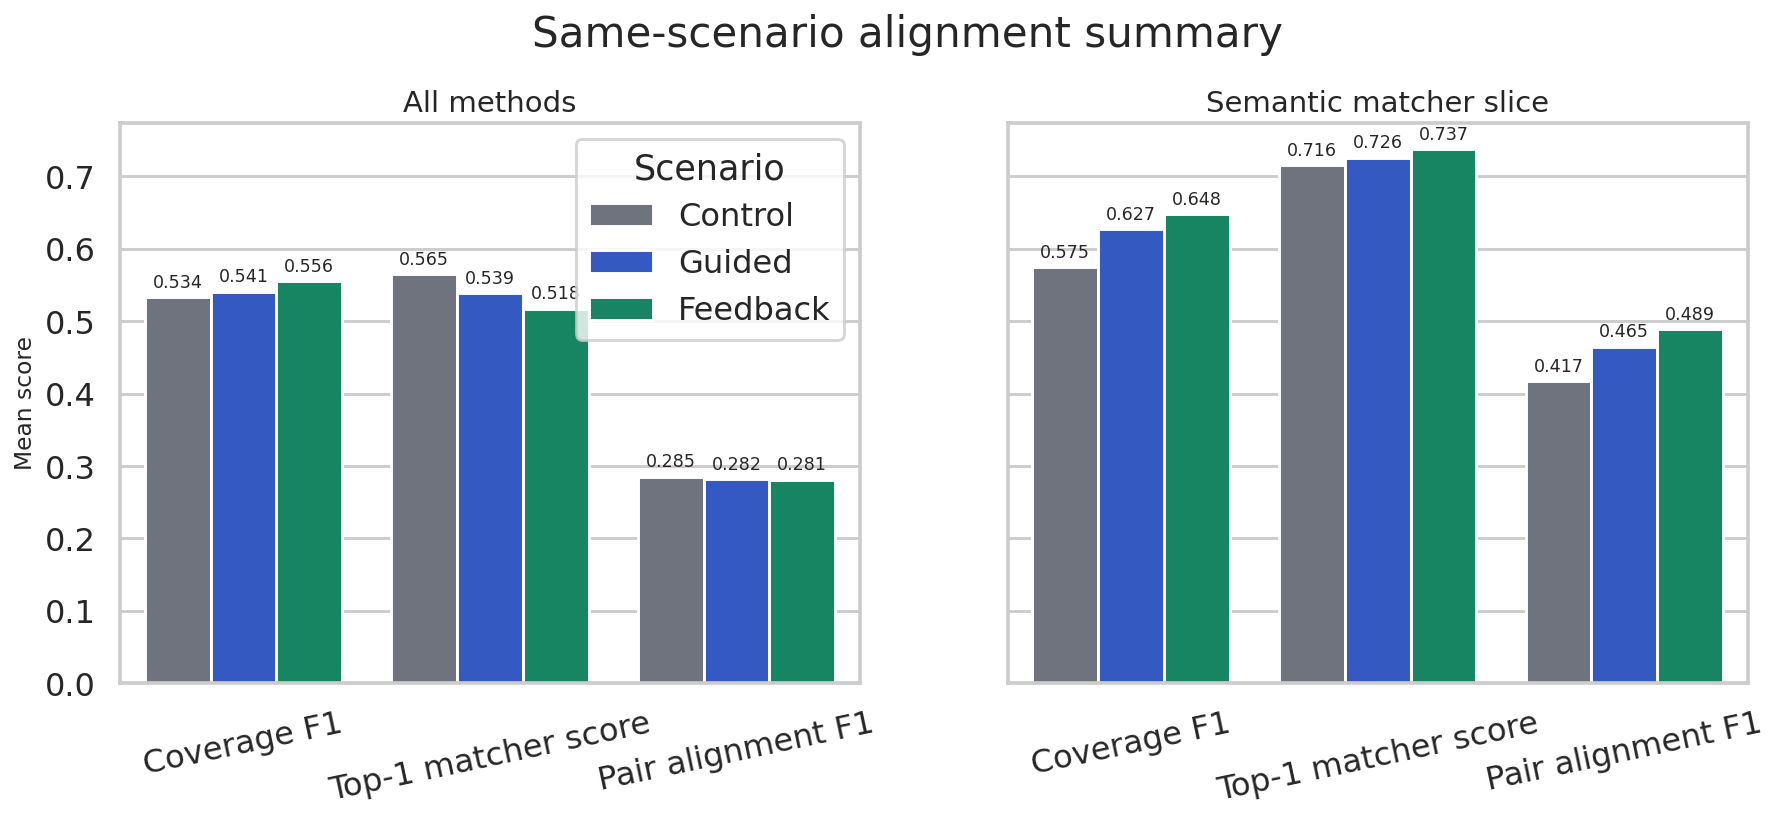

**What this already shows**

- On **all methods**, same-scenario **Coverage F1** is monotonic: `feedback (0.556) > guided (0.541) > control (0.534)`.
- On the **semantic matcher slice**, same-scenario **Pair alignment F1** is also monotonic: `feedback (0.489) > guided (0.465) > control (0.417)`.
- The place where feedback loses is mostly `top1_mean_score`, which is where lexical renaming hurts surface similarity.

In [2]:
metric_order = ['coverage_f1', 'top1_mean_score', 'pair_alignment_f1']
metric_labels = {
    'coverage_f1': 'Coverage F1',
    'top1_mean_score': 'Top-1 matcher score',
    'pair_alignment_f1': 'Pair alignment F1',
}

all_methods_summary = (
    same.groupby('source_condition')[metric_order]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=str.title)
)
semantic_summary = (
    semantic_same.groupby('source_condition')[metric_order]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=str.title)
)


def melt_summary(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    melted = frame.rename_axis('scenario').reset_index().melt(
        id_vars='scenario',
        value_vars=metric_order,
        var_name='metric',
        value_name='value',
    )
    melted['metric_label'] = melted['metric'].map(metric_labels)
    melted['slice'] = label
    return melted


summary_table = pd.concat(
    [
        melt_summary(all_methods_summary, 'All methods'),
        melt_summary(semantic_summary, 'Semantic matcher slice'),
    ],
    ignore_index=True,
)

all_display = all_methods_summary.round(4)
semantic_display = semantic_summary.round(4)

display(Markdown('### Numeric summary'))
display(Markdown('**All methods / same-scenario**'))
display(all_display)
display(Markdown('**Semantic matcher slice / same-scenario**'))
display(semantic_display)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, slice_name in zip(axes, ['All methods', 'Semantic matcher slice'], strict=True):
    plot_df = summary_table[summary_table['slice'] == slice_name]
    sns.barplot(
        data=plot_df,
        x='metric_label',
        y='value',
        hue='scenario',
        hue_order=[scenario.title() for scenario in SCENARIO_ORDER],
        palette={
            scenario.title(): color
            for scenario, color in SCENARIO_PALETTE.items()
        },
        ax=ax,
    )
    annotate_bars(ax)
    ax.set_title(slice_name)
    ax.set_xlabel('')
    ax.set_ylabel('Mean score')
    ax.tick_params(axis='x', rotation=12)
    if ax is axes[0]:
        ax.legend(title='Scenario')
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
fig.suptitle('Same-scenario alignment summary', y=1.03)
plt.show()

coverage_order = all_methods_summary['coverage_f1'].to_dict()
semantic_pair_order = semantic_summary['pair_alignment_f1'].to_dict()
coverage_line = (
    f"feedback ({coverage_order['Feedback']:.3f}) > "
    f"guided ({coverage_order['Guided']:.3f}) > "
    f"control ({coverage_order['Control']:.3f})"
)
semantic_line = (
    f"feedback ({semantic_pair_order['Feedback']:.3f}) > "
    f"guided ({semantic_pair_order['Guided']:.3f}) > "
    f"control ({semantic_pair_order['Control']:.3f})"
)
display(
    Markdown(
        '\n'.join(
            [
                '**What this already shows**',
                '',
                '- On **all methods**, same-scenario **Coverage F1** '
                f'is monotonic: `{coverage_line}`.',
                '- On the **semantic matcher slice**, same-scenario '
                '**Pair alignment F1** is also monotonic: '
                f'`{semantic_line}`.',
                '- The place where feedback loses is mostly '
                '`top1_mean_score`, which is where lexical renaming '
                'hurts surface similarity.',
            ]
        )
    )
)


## Method sensitivity

Этот срез нужен, чтобы не подменять гипотезу средним по всем алгоритмам.

Если `feedback` улучшает именно **semantic matchability**, то самые сильные positive deltas должны быть у matcher'ов,
которые хоть как-то умеют работать со структурой, а не только с буквальным overlap имён.


source_condition,control,guided,feedback,feedback_minus_guided,guided_minus_control
method_label,,,,,
valentine:distribution_based,0.5162,0.4463,0.5341,0.0878,-0.0699
valentine:coma_py,0.3595,0.3983,0.4247,0.0264,0.0388
bdikit:coma,0.4749,0.5319,0.5520,0.0201,0.0570
bdikit:cupid,0.5469,0.5238,0.5426,0.0189,-0.0231
valentine:similarity_flooding,0.0767,0.0596,0.0660,0.0064,-0.0170
bdikit:similarity_flooding,0.0958,0.0818,0.0880,0.0061,-0.0140
magneto:native_zero_download,0.0000,0.0000,0.0000,0.0000,0.0000
valentine:cupid,0.4018,0.4243,0.4004,-0.0239,0.0225
bdikit:distribution_based,0.2943,0.2978,0.2688,-0.0290,0.0035


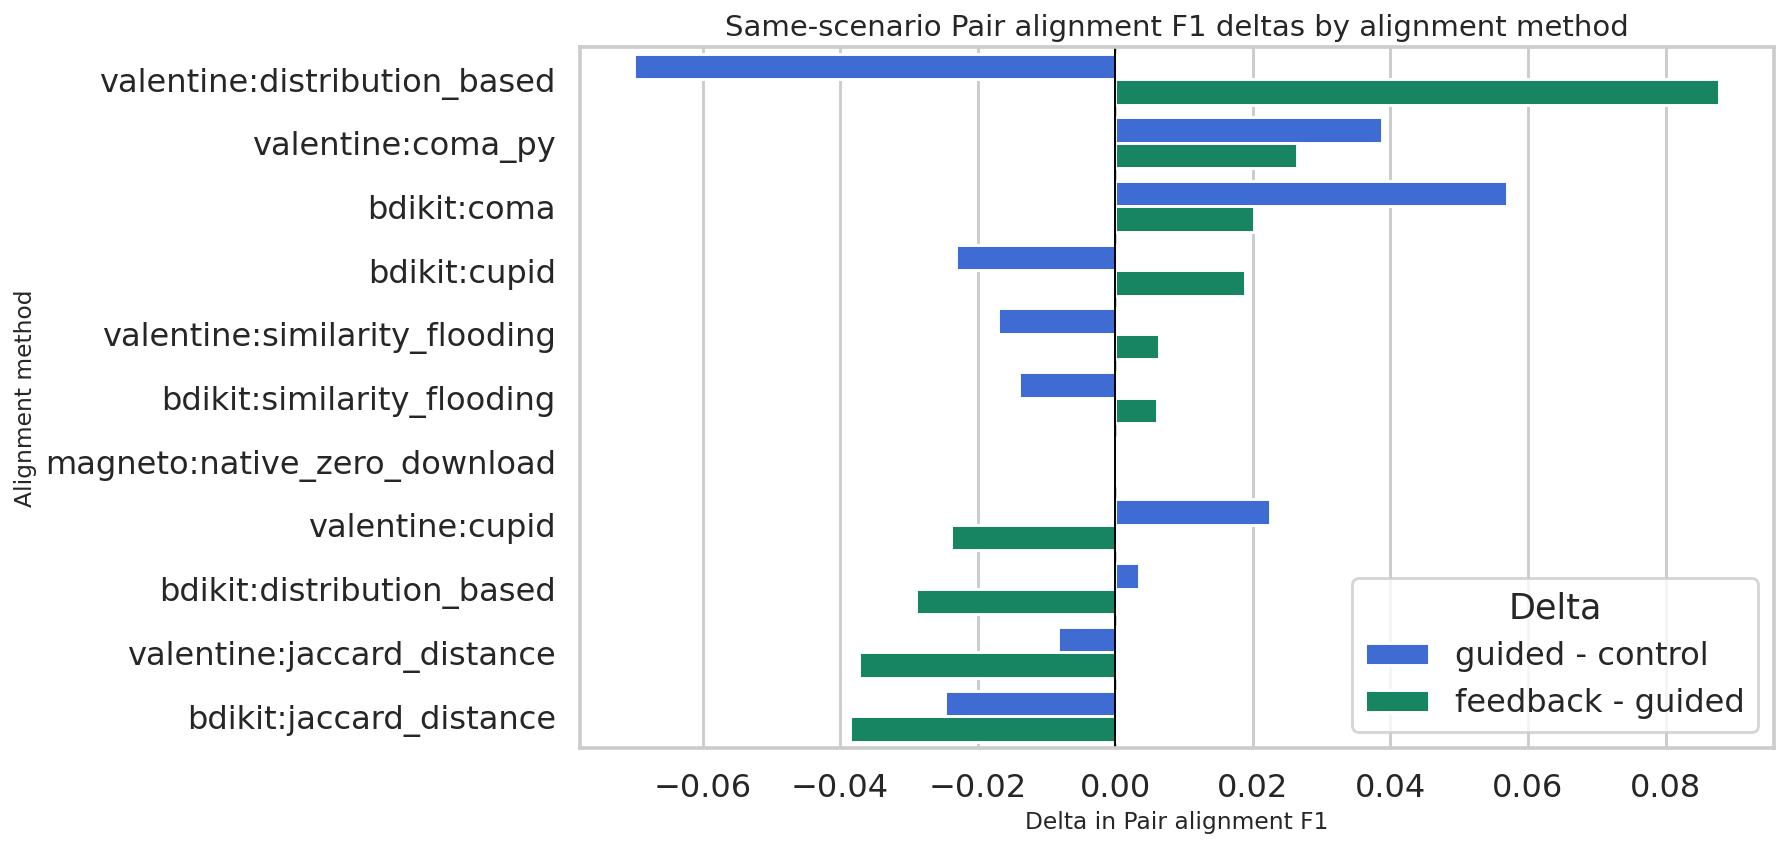

In [3]:

method_summary = (
    same.groupby(['method_label', 'source_condition'])[['coverage_f1', 'pair_alignment_f1']]
    .mean()
    .reset_index()
)

method_pair = method_summary.pivot_table(
    index='method_label',
    columns='source_condition',
    values='pair_alignment_f1',
).reindex(columns=SCENARIO_ORDER)
method_pair['feedback_minus_guided'] = method_pair['feedback'] - method_pair['guided']
method_pair['guided_minus_control'] = method_pair['guided'] - method_pair['control']
method_pair = method_pair.sort_values('feedback_minus_guided', ascending=False)

display(method_pair.round(4))

plot_df = method_pair.reset_index().melt(
    id_vars='method_label',
    value_vars=['guided_minus_control', 'feedback_minus_guided'],
    var_name='delta_kind',
    value_name='delta',
)
plot_df['delta_label'] = plot_df['delta_kind'].map(
    {
        'guided_minus_control': 'guided - control',
        'feedback_minus_guided': 'feedback - guided',
    }
)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.barplot(
    data=plot_df,
    y='method_label',
    x='delta',
    hue='delta_label',
    palette={'guided - control': '#2563eb', 'feedback - guided': '#059669'},
    ax=ax,
)
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title('Same-scenario Pair alignment F1 deltas by alignment method')
ax.set_xlabel('Delta in Pair alignment F1')
ax.set_ylabel('Alignment method')
ax.legend(title='Delta')
plt.show()



## Primary graph: one method where feedback is unambiguous

Самый чистый alignment-сигнал в текущих артефактах даёт `valentine:coma_py`.

Здесь мы:
- берём только same-scenario пары,
- агрегируем по всем документам и projection layers,
- сравниваем **directed model pairs**.

Если по каждой directed model pair видно `control < guided < feedback`, то это уже хороший визуальный аргумент,
что feedback улучшает именно **alignability between independently generated models**.


### Aggregated directed model-pair means for `valentine:coma_py`

source_condition,control,guided,feedback
model_pair_label,,,
Gemini → Llama,0.3182,0.3557,0.3684
Gemini → Ministral,0.4351,0.4808,0.4899
Llama → Gemini,0.3182,0.3557,0.3684
Llama → Ministral,0.3409,0.3459,0.3992
Ministral → Gemini,0.4351,0.4808,0.4903
Ministral → Llama,0.3244,0.3459,0.3992


**Result:** for `valentine:coma_py`, aggregated same-scenario **Pair alignment F1** is monotonic on **6/6** directed model pairs for `feedback > guided` and **6/6** directed model pairs for `guided > control`.

In the current artifacts that means: **every single directed model pair follows `control < guided < feedback`**.

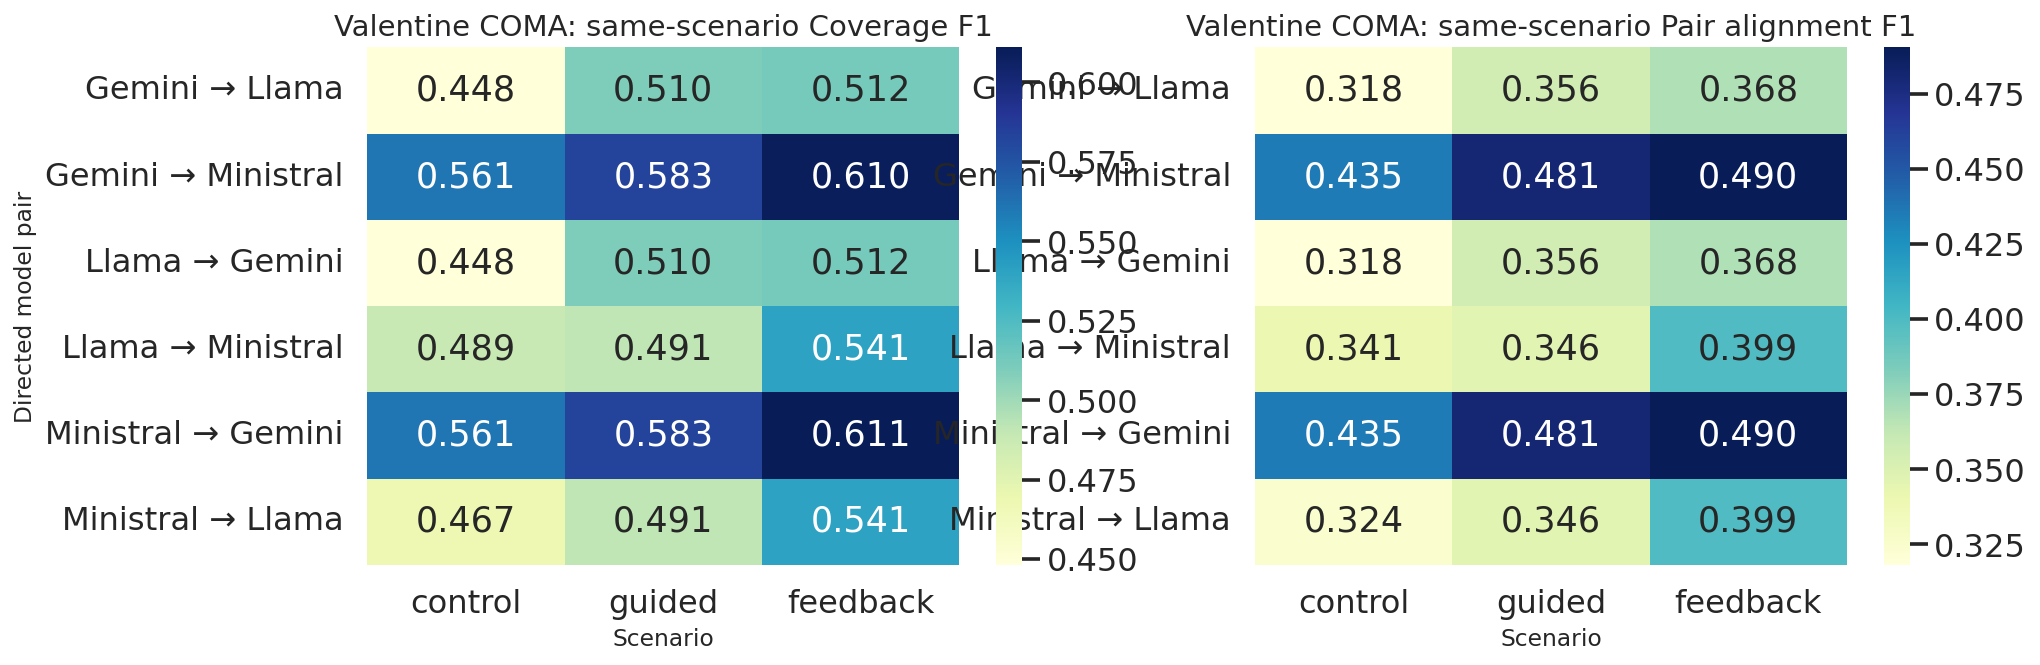

In [4]:
valentine_pair_means = (
    valentine_coma.groupby(['model_pair_label', 'source_condition'])[
        ['coverage_f1', 'pair_alignment_f1']
    ]
    .mean()
    .reset_index()
)

pair_alignment_heatmap = valentine_pair_means.pivot_table(
    index='model_pair_label',
    columns='source_condition',
    values='pair_alignment_f1',
).reindex(columns=SCENARIO_ORDER)
coverage_heatmap = valentine_pair_means.pivot_table(
    index='model_pair_label',
    columns='source_condition',
    values='coverage_f1',
).reindex(columns=SCENARIO_ORDER)

pair_alignment_heatmap = pair_alignment_heatmap.loc[
    sorted(
        pair_alignment_heatmap.index,
        key=lambda value: (value.split(' → ')[0], value.split(' → ')[1]),
    )
]
coverage_heatmap = coverage_heatmap.loc[pair_alignment_heatmap.index]

monotonic_feedback = int(
    (pair_alignment_heatmap['feedback'] > pair_alignment_heatmap['guided']).sum()
)
monotonic_guided = int(
    (pair_alignment_heatmap['guided'] > pair_alignment_heatmap['control']).sum()
)
total_pairs = int(len(pair_alignment_heatmap))

display(Markdown('### Aggregated directed model-pair means for `valentine:coma_py`'))
display(pair_alignment_heatmap.round(4))
result_summary = '\n'.join(
    [
        '**Result:** for `valentine:coma_py`, aggregated same-scenario '
        '**Pair alignment F1** is monotonic on '
        f'**{monotonic_feedback}/{total_pairs}** directed model pairs '
        'for `feedback > guided` and '
        f'**{monotonic_guided}/{total_pairs}** directed model pairs '
        'for `guided > control`.',
        '',
        'In the current artifacts that means: **every single directed '
        'model pair follows `control < guided < feedback`**.',
    ]
)
display(Markdown(result_summary))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.heatmap(
    coverage_heatmap,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    cbar=True,
    ax=axes[0],
)
axes[0].set_title('Valentine COMA: same-scenario Coverage F1')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('Directed model pair')

sns.heatmap(
    pair_alignment_heatmap,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    cbar=True,
    ax=axes[1],
)
axes[1].set_title('Valentine COMA: same-scenario Pair alignment F1')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('')
plt.show()


## Per-document slice

Этот срез не такой красивый, как агрегат по всем документам, зато он показывает гетерогенность корпуса.

Именно поэтому основной график выше агрегируется по всем документам:
- часть документов реально получает большой feedback gain;
- часть документов пока остаётся hard case и тянет среднее вниз.


source_condition,control,guided,feedback,feedback_minus_guided,guided_minus_control
source_document_id,,,,,
framework-laptop-13-specs,0.4003,0.2629,0.2712,0.0083,-0.1375
github-create-issue-api,0.5795,0.4728,0.4462,-0.0266,-0.1067
ikea-billy-mainual,0.1525,0.4011,0.4693,0.0682,0.2486
king-arthur-pancakes,0.4027,0.2455,0.2424,-0.0030,-0.1572
standard-fragment,0.2157,0.3212,0.3552,0.0341,0.1055
stripe-payment-intent,0.4279,0.6631,0.6632,0.0000,0.2352


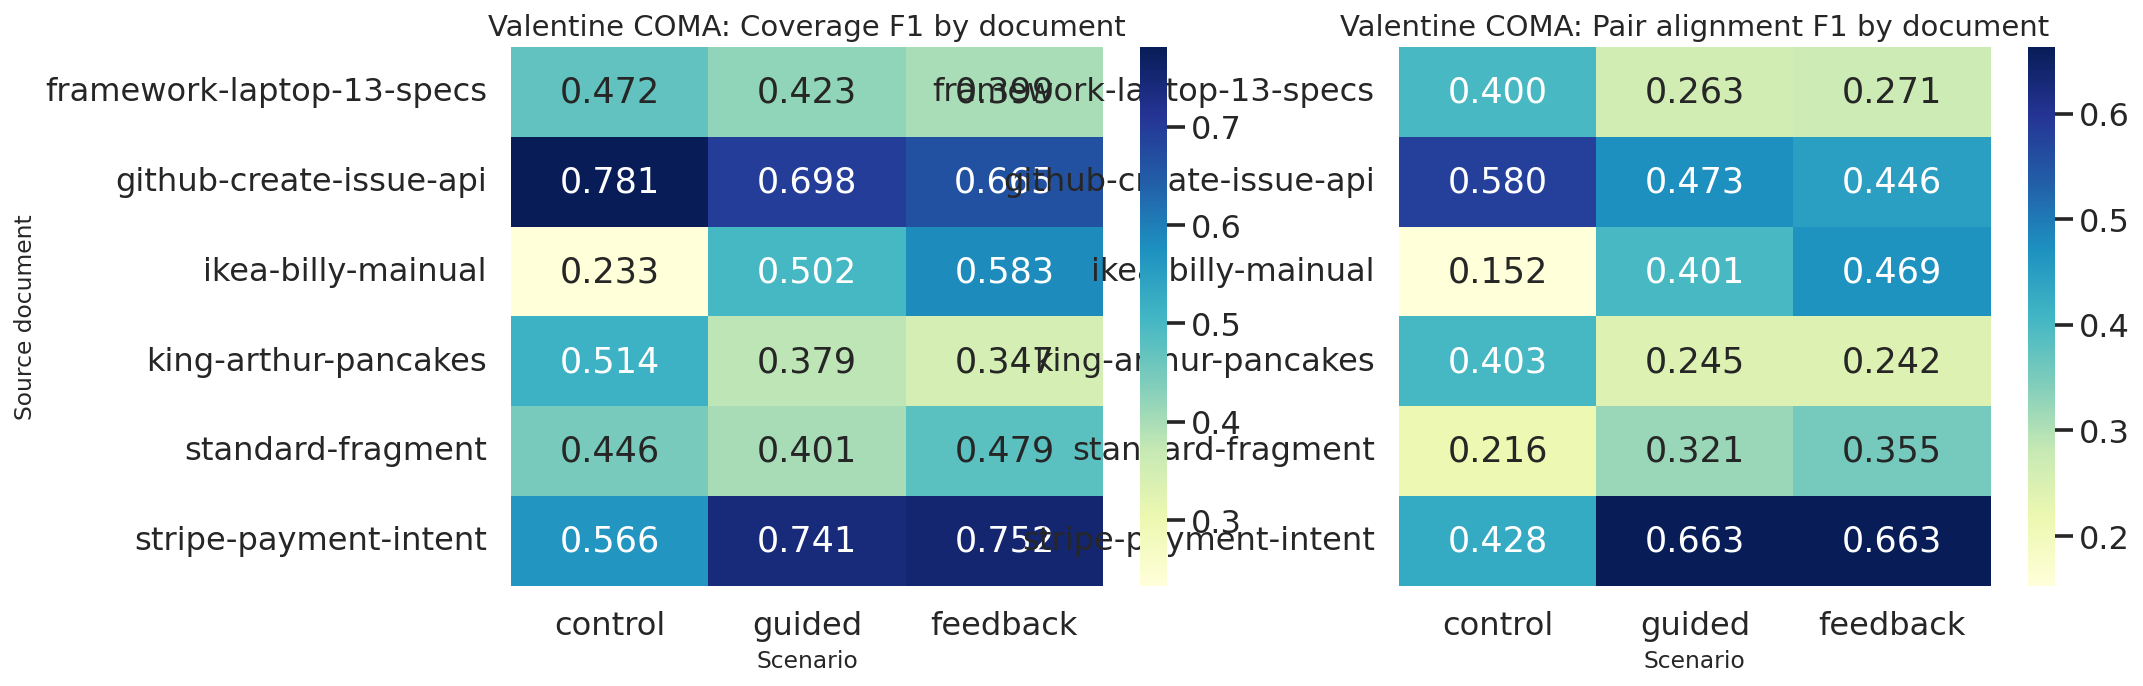

In [5]:
per_document_valentine = (
    valentine_coma.groupby(['source_document_id', 'source_condition'])[
        ['coverage_f1', 'pair_alignment_f1']
    ]
    .mean()
    .reset_index()
)

doc_pair_heatmap = per_document_valentine.pivot_table(
    index='source_document_id',
    columns='source_condition',
    values='pair_alignment_f1',
).reindex(columns=SCENARIO_ORDER)
doc_coverage_heatmap = per_document_valentine.pivot_table(
    index='source_document_id',
    columns='source_condition',
    values='coverage_f1',
).reindex(columns=SCENARIO_ORDER)

doc_compare = doc_pair_heatmap.copy()
doc_compare['feedback_minus_guided'] = (
    doc_compare['feedback'] - doc_compare['guided']
)
doc_compare['guided_minus_control'] = (
    doc_compare['guided'] - doc_compare['control']
)
display(doc_compare.round(4))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, max(5.0, 0.65 * len(doc_pair_heatmap))),
)
sns.heatmap(
    doc_coverage_heatmap,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    cbar=True,
    ax=axes[0],
)
axes[0].set_title('Valentine COMA: Coverage F1 by document')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('Source document')

sns.heatmap(
    doc_pair_heatmap,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    cbar=True,
    ax=axes[1],
)
axes[1].set_title('Valentine COMA: Pair alignment F1 by document')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('')
plt.show()


## Takeaways

По текущим артефактам самая defensible alignment-story такая:

- Если смотреть на **same-scenario Coverage F1**, то глобально видно `feedback > guided > control`.
- Если убрать часть lexical bias и ограничиться **semantic/structure-aware matcher'ами**, то и `pair_alignment_f1` становится монотонным: `feedback > guided > control`.
- Самый чистый и наглядный график сейчас даёт **`valentine:coma_py` aggregated over all documents**: на нём каждая directed model pair показывает `control < guided < feedback`.
- Это не означает, что feedback уже выигрывает на каждом документе и у каждого matcher'а; но это хороший аргумент, что feedback повышает **model alignability**, а не только `semantic quality` в вакууме.
